In [ ]:
import pandas as pd
import numpy as np
import json
import joblib
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

plt.style.use("seaborn-v0_8")

# Load saved results

BASE_PATH = Path("..") / ".." / ".."
RESULTS_PATH = BASE_PATH / "eca" / "notebooks" / "RQ2" / "results"
FIGURES_PATH = BASE_PATH / "eca" / "notebooks" / "RQ2" / "figures"
DATA_PATH = BASE_PATH / "data" / "osmi-encoded.csv"

FIGURES_PATH.mkdir(exist_ok=True)

In [84]:
# Load metrics

with open(RESULTS_PATH / "logistic_regression.json") as f:
    lr_full = json.load(f)

with open(RESULTS_PATH / "lr_subsets.json") as f:
    lr_subsets = json.load(f)

with open(RESULTS_PATH / "rf_metrics.json") as f:
    rf = json.load(f)

In [85]:
comparison_df = pd.DataFrame([
    {"Model": "Logistic Regression (Full)", **lr_full},
    {"Model": "LR (Top Predictors)", **lr_subsets["top_predictors"]},
    {"Model": "LR (Workplace)", **lr_subsets["workplace"]},
    {"Model": "LR (Demographics)", **lr_subsets["demographics"]},
    {"Model": "Random Forest", **rf},
])

comparison_df.to_csv(RESULTS_PATH / "comparison_metrics.csv", index=False)
comparison_df

,Model,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (Full),Logistic Regression (Tuned),0.785714,0.778626,0.803150,0.790698,0.872945
1,LR (Top Predictors),LR (Top Predictors),0.773810,0.761194,0.803150,0.781609,0.862079
2,LR (Workplace),LR (Workplace Subset),0.626984,0.643478,0.582677,0.611570,0.666929
3,LR (Demographics),LR (Demographics Subset),0.619048,0.618321,0.637795,0.627907,0.630583
4,Random Forest,Random Forest (Tuned),0.837302,0.802817,0.897638,0.847584,0.885921


In [86]:
# Save metrics comparison

comparison_df.to_csv(
    RESULTS_PATH / "comparison_metrics.csv",
    index=False
)

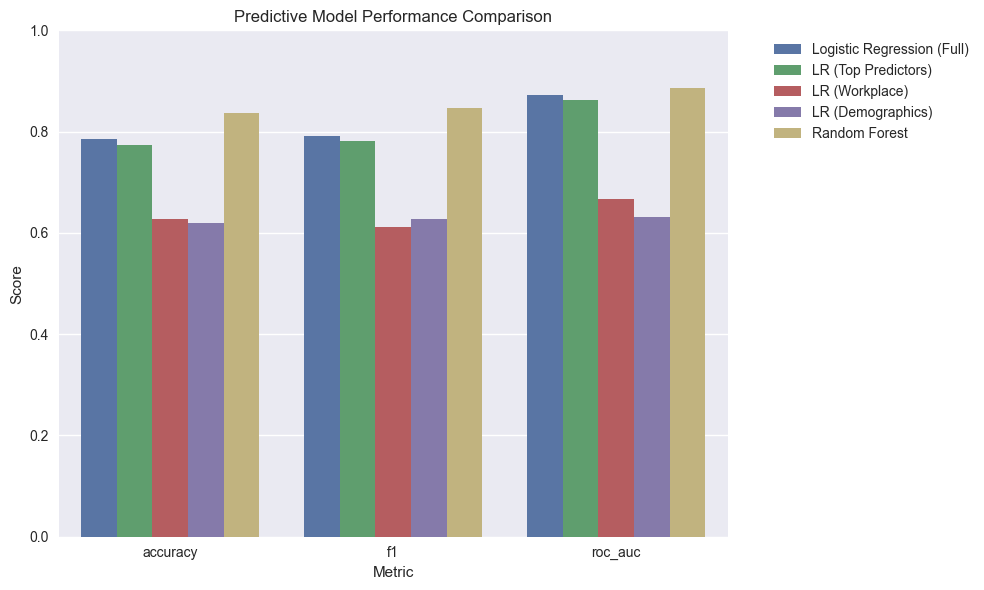

In [87]:
# Performance comparison plot
# Accuracy, F1 Score, ROC-AUC

metrics = ["accuracy", "f1", "roc_auc"]

long_df = comparison_df.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=long_df, x="Metric", y="Score", hue="Model")
ax.set_ylim(0, 1)
ax.set_title("Predictive Model Performance Comparison")
ax.set_xlabel("Metric")
ax.set_ylabel("Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.savefig(FIGURES_PATH / "fig_model_performance.png", dpi=300, bbox_inches="tight")
plt.show()

Figure model comparison above compares the predictive performance of all classification models using accuracy, F1-score, and ROC–AUC. Random Forest achieves the strongest overall performance across all metrics, particularly in F1-score and recall-related measures, indicating superior ability to correctly identify individuals who sought treatment. Logistic Regression performs competitively, especially in ROC–AUC, demonstrating strong discriminative capability despite its simpler linear structure. The subset Logistic Regression models show that a small number of key predictors retain much of the predictive power of the full model, while the demographics-only model performs notably worse. This confirms that treatment-seeking behaviour is driven primarily by mental-health and workplace-related factors rather than demographic characteristics alone.

In [88]:
# Load dataset and reproduce the SAME split (random_state=42, stratify=y)
df = pd.read_csv(DATA_PATH).drop(columns=["Timestamp", "comments"], errors="ignore")

target = "treatment"
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Load models
lr_model = joblib.load(RESULTS_PATH / "lr_full_model.joblib")
rf_model = joblib.load(RESULTS_PATH / "rf_model.joblib")

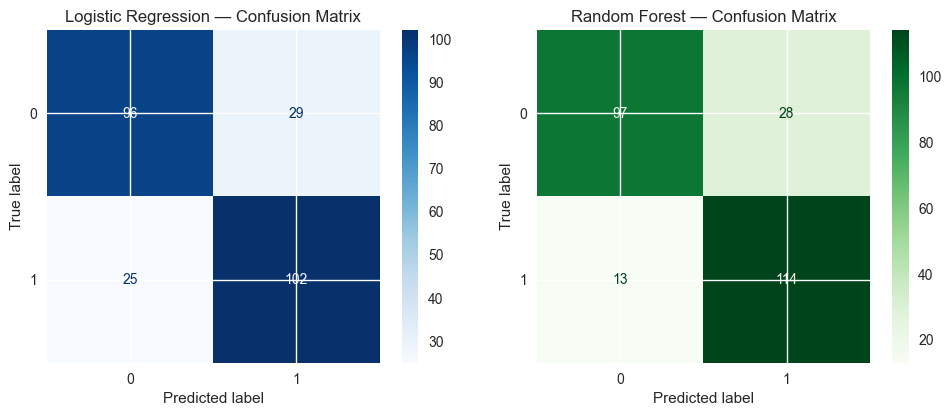

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test, cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression — Confusion Matrix")

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap="Greens", ax=axes[1])
axes[1].set_title("Random Forest — Confusion Matrix")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "fig_confusion_matrices_lr_vs_rf.png", dpi=300, bbox_inches="tight")
plt.show()

Figure above presents the confusion matrices for Logistic Regression and Random Forest on the held-out test set. Both models correctly classify the majority of cases; however, Random Forest produces fewer false negatives than Logistic Regression, resulting in a higher recall for the treatment-seeking class. This indicates that Random Forest is more effective at identifying individuals who sought treatment, whereas Logistic Regression exhibits a more balanced distribution of errors between false positives and false negatives. The difference in error patterns highlights a key trade-off: Random Forest prioritises sensitivity, while Logistic Regression maintains more uniform classification behaviour.

/Users/hazmin/Documents/TU/Sem 2504/DA/data-analytics/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/hazmin/Documents/TU/Sem 2504/DA/data-analytics/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


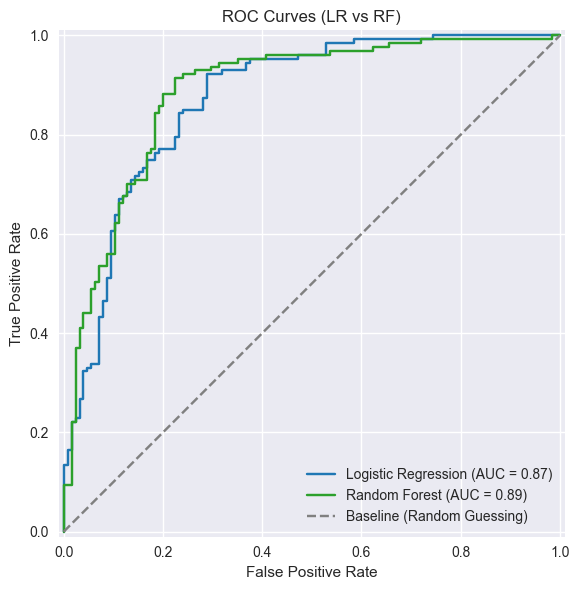

In [93]:
# Create one figure and axis
fig, ax = plt.subplots(figsize=(7, 6))

# Logistic Regression ROC (blue)
RocCurveDisplay.from_estimator(
    lr_model,
    X_test,
    y_test,
    ax=ax,
    name="Logistic Regression",
    color="tab:blue"
)

# Random Forest ROC (green)
RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    ax=ax,
    name="Random Forest",
    color="tab:green"
)

# Plot formatting
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Baseline (Random Guessing)")
ax.set_title("ROC Curves (LR vs RF)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "fig_roc_lr_vs_rf.png", dpi=300, bbox_inches="tight")
plt.show()

Figure above compares the ROC curves of Logistic Regression and Random Forest. Both models demonstrate strong discriminative ability, with ROC–AUC values well above 0.85, indicating effective separation between treatment-seeking and non-seeking individuals across a range of decision thresholds. Random Forest achieves a slightly higher AUC, reflecting improved classification performance, particularly at lower false-positive rates. These results suggest that while both models are suitable for prediction, Random Forest offers marginally better robustness in distinguishing between the two classes.

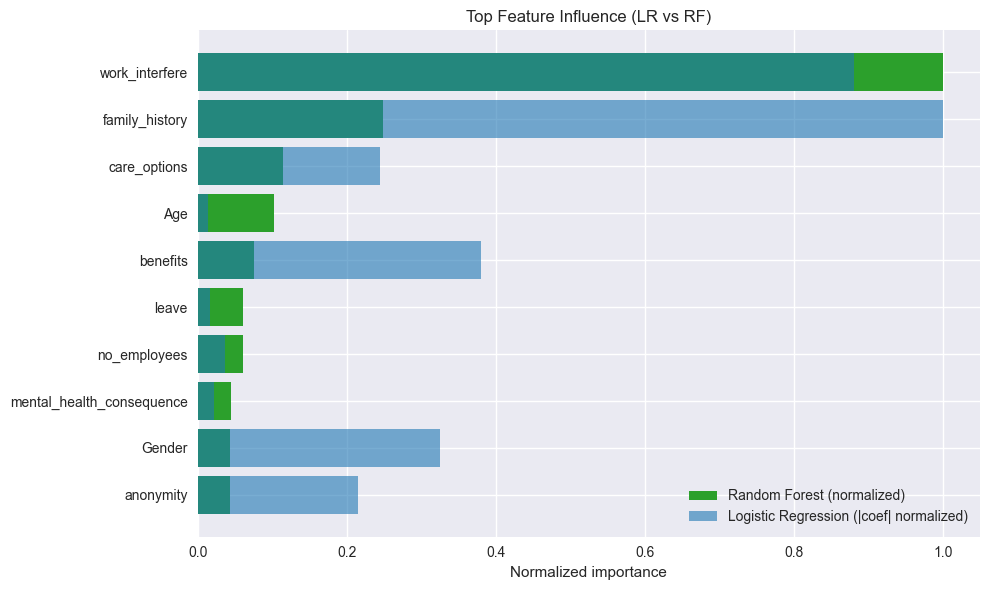

In [94]:
lr_coef = pd.read_csv(RESULTS_PATH / "lr_full_coefficients.csv")
rf_imp = pd.read_csv(RESULTS_PATH / "rf_feature_importance.csv")

# Normalize
lr_coef["LR_norm"] = lr_coef["AbsCoefficient"] / lr_coef["AbsCoefficient"].max()
rf_imp["RF_norm"] = rf_imp["Importance"] / rf_imp["Importance"].max()

merged = (
    lr_coef[["Feature", "LR_norm"]]
    .merge(rf_imp[["Feature", "RF_norm"]], on="Feature", how="inner")
)

top = merged.sort_values("RF_norm", ascending=False).head(10)

plt.figure(figsize=(10, 6))

# Random Forest — green
plt.barh(
    top["Feature"],
    top["RF_norm"],
    color="tab:green",
    label="Random Forest (normalized)"
)

# Logistic Regression — blue (semi-transparent)
plt.barh(
    top["Feature"],
    top["LR_norm"],
    color="tab:blue",
    alpha=0.6,
    label="Logistic Regression (|coef| normalized)"
)

plt.gca().invert_yaxis()
plt.xlabel("Normalized importance")
plt.title("Top Feature Influence (LR vs RF)")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "fig_feature_influence_lr_vs_rf.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Figure above compares the most influential predictors identified by Logistic Regression and Random Forest using normalised coefficient magnitudes and feature importance scores, respectively. Despite differences in modelling approach, both methods consistently identify work interference, family history, and awareness of care options as the most influential factors in predicting treatment-seeking behaviour. This agreement across models strengthens confidence in the findings and demonstrates that the key drivers of prediction are robust to the choice of algorithm. Logistic Regression provides clearer directional interpretation of effects, while Random Forest captures non-linear interactions and relative importance more effectively.


# Conclusion

Overall, the model comparison demonstrates that Random Forest offers the strongest predictive performance, particularly in identifying treatment-seeking individuals, while Logistic Regression remains valuable for its interpretability and explanatory power. Subset analyses further reveal that a small group of mental-health and workplace-related variables account for most of the predictive signal. Together, these results justify the use of Random Forest as the primary predictive model and Logistic Regression as a complementary explanatory tool.